In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup paths
base_dir = Path.cwd().parent
processed_data_dir = base_dir / 'data' / 'processed'
models_dir = base_dir / 'models' / 'text_encoder'
visuals_dir = base_dir / 'visualizations'

models_dir.mkdir(parents=True, exist_ok=True)
visuals_dir.mkdir(parents=True, exist_ok=True)

print("Loading Master Text Dataset...")
text_path = processed_data_dir / 'master_text_data.csv'
df_text = pd.read_csv(text_path)
df_text = df_text.dropna()

print(f"Dataset loaded successfully. Total records: {df_text.shape[0]}")

Loading Master Text Dataset...
Dataset loaded successfully. Total records: 81729


In [2]:
print("Preparing Data and Encoding Labels...")

# Encode labels to numerical format
label_mapping = {'Safe': 0, 'Web_Attack': 1, 'LLM_Attack': 2}
df_text['target'] = df_text['label'].map(label_mapping)

X = df_text['text']
y = df_text['target']

# Stratified split to ensure rare classes are distributed evenly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")

print("\nApplying TF-IDF Vectorization (Character N-Grams)...")
# Using character boundaries (char_wb) to catch sub-word malicious patterns
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=15000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"Vectorization complete. Feature vocabulary size: {len(tfidf.get_feature_names_out())}")

Preparing Data and Encoding Labels...
Training Samples: 65383
Testing Samples: 16346

Applying TF-IDF Vectorization (Character N-Grams)...
Vectorization complete. Feature vocabulary size: 15000


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

print("Converting Text to Numbers using TF-IDF Vectorizer...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("\n[*] Data Balancing...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

print(f" -> Original Training Samples: {X_train_vec.shape[0]}")
print(f" -> SMOTE Resampled Samples: {X_train_resampled.shape[0]}")

print("\n[*] Training the Text Logistic Regression...")
# 🚨 Notice: class_weight parameter is REMOVED! The model will not be biased anymore.
text_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
text_model.fit(X_train_resampled, y_train_resampled)

print("\nModel trained successfully")

Converting Text to Numbers using TF-IDF Vectorizer...

[*] Data Balancing...
 -> Original Training Samples: 65383
 -> SMOTE Resampled Samples: 167286

[*] Training the Text Logistic Regression...

Model trained successfully


Evaluating Model Performance...

Final Model Accuracy: 99.2231%

Classification Report (With Custom Thresholds):
              precision    recall  f1-score   support

        Safe       1.00      0.99      1.00     13941
  Web_Attack       1.00      0.99      1.00      2353
  LLM_Attack       0.32      0.88      0.47        52

    accuracy                           0.99     16346
   macro avg       0.77      0.96      0.82     16346
weighted avg       1.00      0.99      0.99     16346



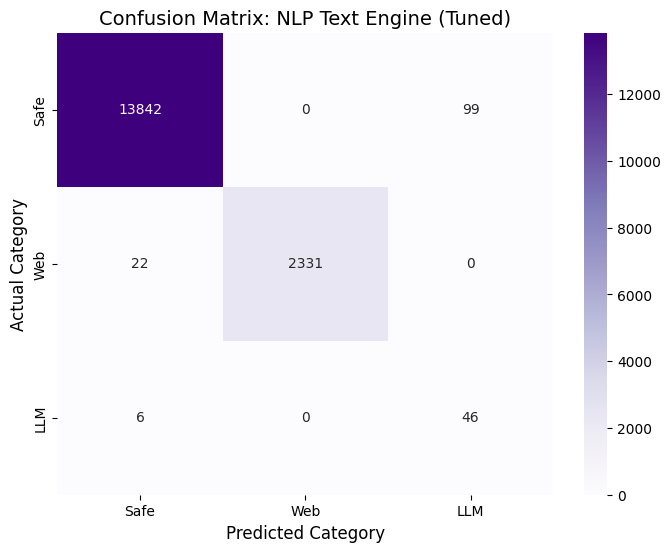

Model and Vectorizer successfully saved to c:\Users\induw\OneDrive\Documents\SENTIO_360_Project\models\text_encoder


In [4]:
print("Evaluating Model Performance...\n")

# Get exact probabilities instead of blind predictions
y_pred_probs = text_model.predict_proba(X_test_vec)

y_pred_custom = []
for probs in y_pred_probs:
    prob_safe = probs[0]
    prob_web = probs[1]
    prob_llm = probs[2]
    
    if prob_llm > 0.65:
        y_pred_custom.append(2) # LLM Attack
    elif prob_web > 0.60:
        y_pred_custom.append(1) # Web Attack
    else:
        y_pred_custom.append(0) # Safe (Ignore false alarms like "how are you")

y_pred_custom = np.array(y_pred_custom)

acc = accuracy_score(y_test, y_pred_custom)

print(f"Final Model Accuracy: {acc * 100:.4f}%\n")

print("Classification Report (With Custom Thresholds):")
print(classification_report(y_test, y_pred_custom, target_names=['Safe', 'Web_Attack', 'LLM_Attack']))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Safe', 'Web', 'LLM'], yticklabels=['Safe', 'Web', 'LLM'])
plt.title('Confusion Matrix: NLP Text Engine (Tuned)', fontsize=14)
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.savefig(visuals_dir / '07_text_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Export Model
model_path = models_dir / 'lr_text_model.pkl'
tfidf_path = models_dir / 'tfidf_vectorizer.pkl'

joblib.dump(text_model, model_path)
joblib.dump(tfidf, tfidf_path)
print(f"Model and Vectorizer successfully saved to {models_dir}")